In [1]:
using Piccolo
using LinearAlgebra
using CairoMakie


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
δ = -0.4
sys = TransmonSystem(levels = 3, δ = δ, drive_bounds = [0.5, 0.5], multiply_by_2π = false)
U_goal = EmbeddedOperator(:X, sys)

EmbeddedOperator{ComplexF64}(ComplexF64[0.0 + 0.0im 1.0 + 0.0im 0.0 + 0.0im; 1.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im], [1, 2], [3])

In [3]:
const super_duper_value = 0.598144006661 # integral from -1/2 to 1/2 of e^(-8u^2)
λ = √2
Δ = - 2π * 400 / 1000

function gaussian_curve(T, N)
    A = π / (T * (super_duper_value - ℯ^(-2))) / 2
    μ = T / 2
    σ = T / 4

    times = collect(range(0, T, length = N))
    
    function f(t)
        return A * (ℯ^(-(t - μ)^2 / (2σ^2)) - ℯ^(-2))
    end

    function f_prime(t)
        return A * ℯ^(-(t - μ)^2 / (2σ^2)) * ((μ - t)/σ^2)
    end

    println(sum((f.(times[1:end-1]) + f.(times[2:end]))/2) * T / N)
    println(f(times[1]))
    println(f(times[end]))

    E_π = f.(times)
    Ė_π = f_prime.(times)
    return times, E_π, Ė_π
end

function drag_gaussian(T, N)
    times, E_π, Ė_π = gaussian_curve(T, N)
    E_x = E_π .+ ((λ^2-4)/(8Δ^2) * E_π .^ 3) - ((13λ^4 - 76λ^2 + 112) / 128Δ^4 * E_π .^ 5)
    E_y = -Ė_π ./ Δ + ((33(λ^2-2)/24Δ^3) * E_π .^2 .* Ė_π)
    return times, E_x, E_y
end

drag_gaussian (generic function with 1 method)

In [ ]:
T = 20.0
N = 200

controls = zeros(2, N)
times, gaussian, _ = gaussian_curve(T, N)
controls[1, :] .= gaussian
pulse_gauss = ZeroOrderPulse(controls, times)

ZeroOrderPulse
  drives: 2
  duration: 20.0

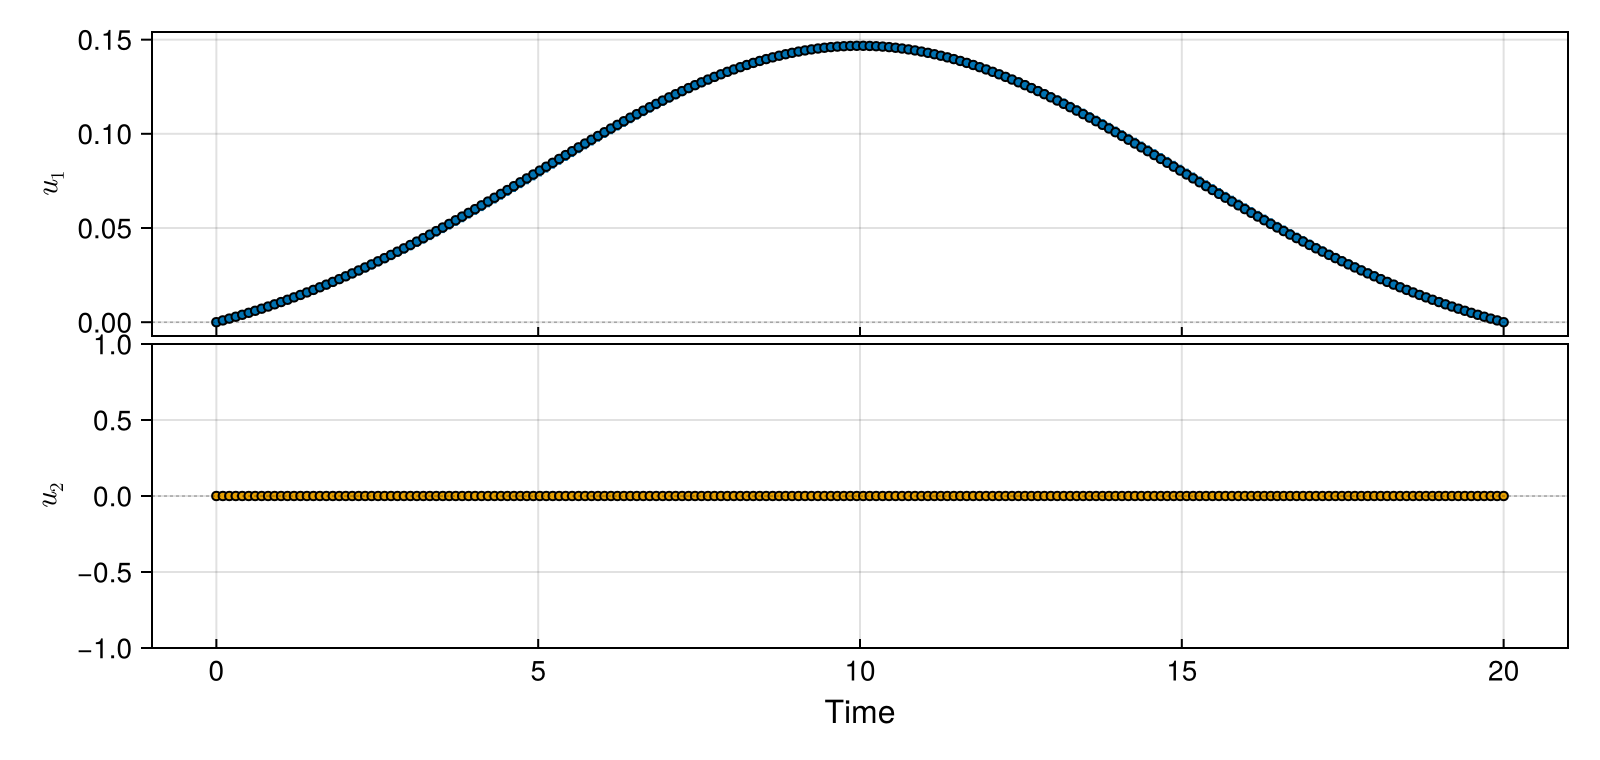

In [31]:
plot_pulse(pulse_gauss)

In [9]:
traj_gauss = UnitaryTrajectory(sys, pulse_gauss, U_goal)
out_gauss = rollout(traj_gauss)
println(1 - fidelity(out_gauss))

0.15357675230669787


In [10]:
qcp_gauss = SmoothPulseProblem(traj_gauss, N)

constructing SmoothPulseProblem [UnitaryTrajectory]


┌ Warning: Trajectory has timestep variable :Δt but no bounds on it.
│ Adding default lower bound of 0 to prevent negative timesteps.
│ 
│ Recommended: Add explicit bounds when creating the trajectory:
│   NamedTrajectory(...; Δt_bounds=(min, max))
│ Example:
│   NamedTrajectory(qtraj, N; Δt_bounds=(1e-3, 0.5))
│ 
│ Or use timesteps_all_equal=true in problem options to fix timesteps.
└ @ DirectTrajOpt.Problems /Users/bordeim1/.julia/packages/DirectTrajOpt/VOKy2/src/problems.jl:66


QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=3   drives=2
│  
├─ Trajectory
│    N=200   T=20.000   Δt∈[0, Inf]
│    Ũ⃗    (18)  ±[1.0, 1.0, 1.0, … (18 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.5, 0.5]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [3], subspace dim 2
│  
├─ Objective   total = 15.36  @ current x
│    KnotPointObjective           w=1             15.36
│    QuadraticRegularizer(:u)     w=1             8.609e-05
│    QuadraticRegularizer(:du)    w=1             2.451e-06
│    QuadraticRegularizer(:ddu)   w=1             1.379e-07
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 violated at 

QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=3   drives=2
│  
├─ Trajectory
│    N=200   T=20.000   Δt∈[0, Inf]
│    Ũ⃗    (18)  ±[1.0, 1.0, 1.0, … (18 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.5, 0.5]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [3], subspace dim 2
│  
├─ Objective   total = 15.36  @ current x
│    KnotPointObjective           w=1             15.36
│    QuadraticRegularizer(:u)     w=1             8.609e-05
│    QuadraticRegularizer(:du)    w=1             2.451e-06
│    QuadraticRegularizer(:ddu)   w=1             1.379e-07
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 violated at 

In [11]:
plot_unitary_populations(get_trajectory(qcp_gauss))
fid_gauss = fidelity(qcp_gauss)

0.8464232476933021

1.5629269571641078
0.0
0.0


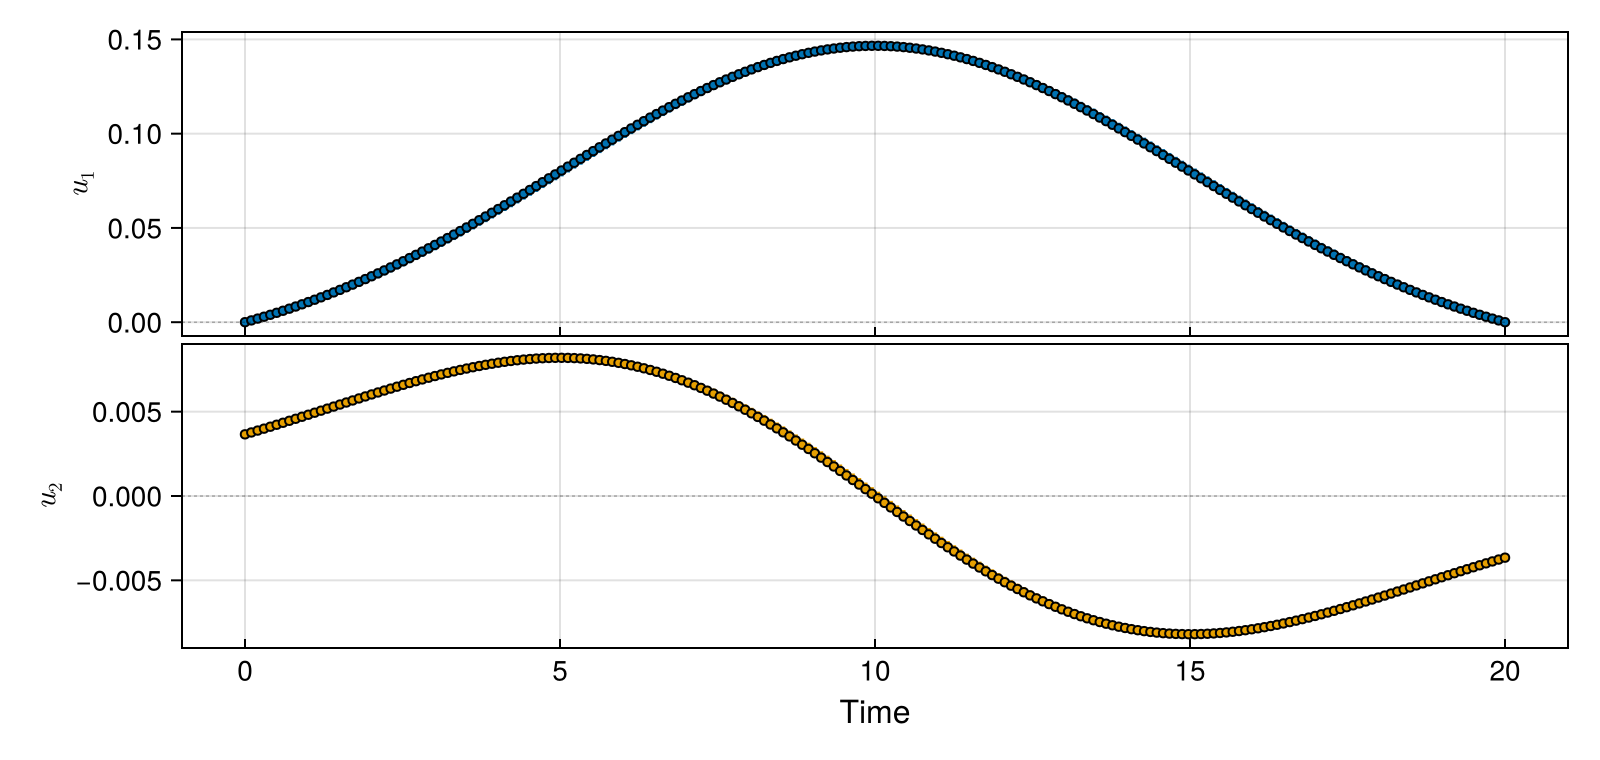

In [12]:
controls = zeros(2, N)
times, controls[1, :], controls[2, :] = drag_gaussian(T, N)
pulse_drag_gaussian = ZeroOrderPulse(controls, times)
plot_pulse(pulse_drag_gaussian)

In [13]:
traj_drag_gauss = UnitaryTrajectory(sys, pulse_drag_gaussian, U_goal)
out_drag_gauss = rollout(traj_drag_gauss)
println(1 - fidelity(out_drag_gauss))

0.09451515920051468


In [14]:
qcp_drag_gauss = SmoothPulseProblem(traj_drag_gauss, N)
fid_drag_gauss = fidelity(qcp_drag_gauss)

constructing SmoothPulseProblem [UnitaryTrajectory]
QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=3   drives=2
│  
├─ Trajectory
│    N=200   T=20.000   Δt∈[0, Inf]
│    Ũ⃗    (18)  ±[1.0, 1.0, 1.0, … (18 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.5, 0.5]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [3], subspace dim 2
│  
├─ Objective   total = 9.452  @ current x
│    KnotPointObjective           w=1             9.452
│    QuadraticRegularizer(:u)     w=1             8.638e-05
│    QuadraticRegularizer(:du)    w=1             2.469e-06
│    QuadraticRegularizer(:ddu)   w=1             1.398e-07
│    NullObjective                w=1 

0.9054848407994853

In [ ]:
solve!(qcp_drag_gauss; max_iter=100, eval_hessian = false)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.9.0.

Number of nonzeros in equality constraint Jacobian...:   227746
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     5177
                     variables with only lower bounds:      200
                variables with lower and upper bounds:     4378
                     variables with only upper bounds:        0
Total number of equality constraints.................:     4577
Total number of inequality c

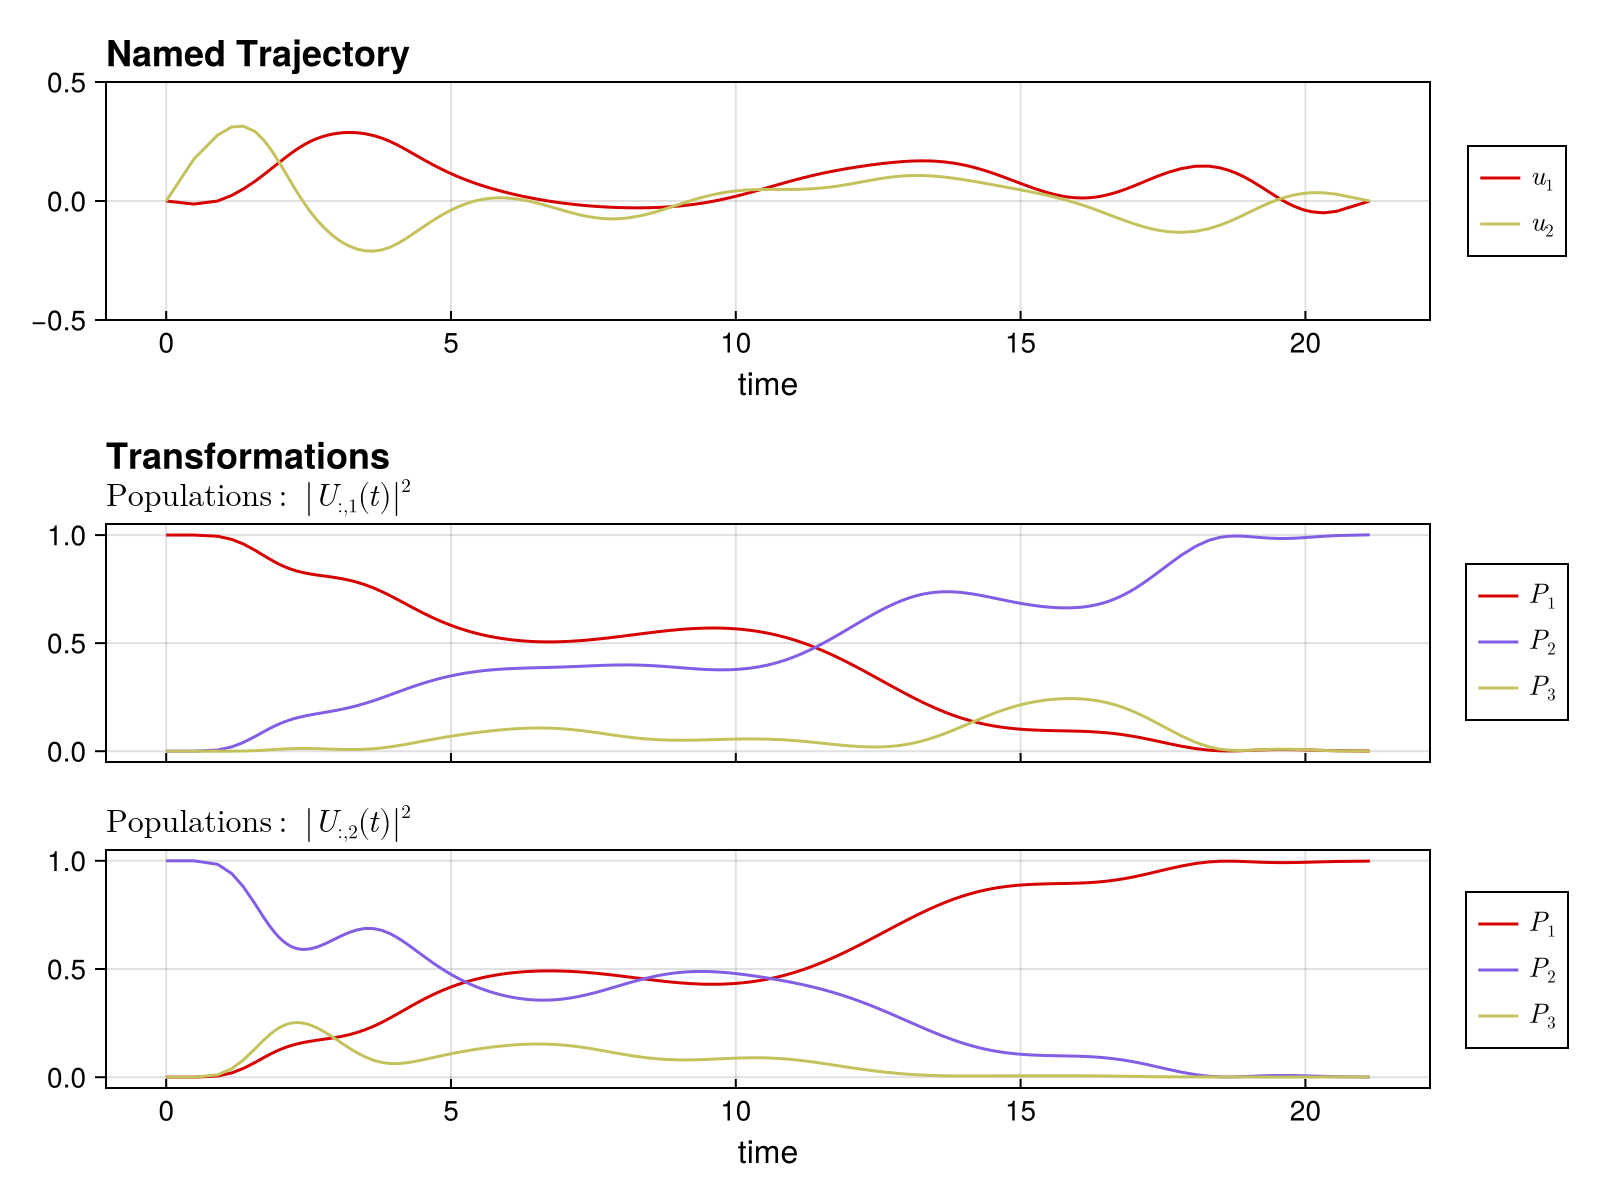

In [16]:
fid_solved_drag_gauss = fidelity(qcp_drag_gauss)
plot_unitary_populations(get_trajectory(qcp_drag_gauss))

# Fidelity Comparison

In [17]:
#For T, N = 20, 200
println("Fidelity of Gauss: ", fid_gauss)
println("Fidelity of DRAG-Gauss: ", fid_drag_gauss)
println("Fidelity of Solved DRAG-Gauss: ", fid_solved_drag_gauss)

Fidelity of Gauss: 0.8464232476933021
Fidelity of DRAG-Gauss: 0.9054848407994853
Fidelity of Solved DRAG-Gauss: 0.998983357123887


In [4]:
N = 100
function fid_gauss_check(T)
    controls = zeros(2, N)
    times, gaussian, _ = gaussian_curve(T, N)
    controls[1, :] .= gaussian
    pulse_gauss = ZeroOrderPulse(controls, times)
    traj_gauss = UnitaryTrajectory(sys, pulse_gauss, U_goal)
    qcp_gauss = SmoothPulseProblem(traj_gauss, N)
    return Piccolo.fidelity(qcp_gauss)
end


function fid_DRAG_gauss_check(T)
    controls = zeros(2, N)
    times, controls[1, :], controls[2, :] = drag_gaussian(T, N)
    pulse_drag_gaussian = ZeroOrderPulse(controls, times)
    traj_drag_gauss = UnitaryTrajectory(sys, pulse_drag_gaussian, U_goal)
    qcp_drag_gauss = SmoothPulseProblem(traj_drag_gauss, N)
    return Piccolo.fidelity(qcp_drag_gauss)
end

fids_gauss = []
fids_DRAG_gauss = []
#These units are in nanoseconds
length = 100
for i in range(1, length; length = length)
    push!(fids_gauss, fid_gauss_check(i))
    push!(fids_DRAG_gauss, fid_DRAG_gauss_check(i))
end


1.55502650193512
0.0
0.0
constructing SmoothPulseProblem [UnitaryTrajectory]


┌ Warning: Trajectory has timestep variable :Δt but no bounds on it.
│ Adding default lower bound of 0 to prevent negative timesteps.
│ 
│ Recommended: Add explicit bounds when creating the trajectory:
│   NamedTrajectory(...; Δt_bounds=(min, max))
│ Example:
│   NamedTrajectory(qtraj, N; Δt_bounds=(1e-3, 0.5))
│ 
│ Or use timesteps_all_equal=true in problem options to fix timesteps.
└ @ DirectTrajOpt.Problems /Users/bordeim1/.julia/packages/DirectTrajOpt/VOKy2/src/problems.jl:66


QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=3   drives=2
│  
├─ Trajectory
│    N=100   T=1.000   Δt∈[0, Inf]
│    Ũ⃗    (18)  ±[1.0, 1.0, 1.0, … (18 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.5, 0.5]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [3], subspace dim 2
│  
├─ Objective   total = 78.09  @ current x
│    KnotPointObjective           w=1             78.04
│    QuadraticRegularizer(:u)     w=1             1.731e-04
│    QuadraticRegularizer(:du)    w=1             1.974e-03
│    QuadraticRegularizer(:ddu)   w=1             0.04421
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 violated at x₀


In [5]:
function x0_checker(lst, tolerance)
    for i in range(1,size(lst,1))
        if lst[i] > tolerance
            return i
        end
    end
end


x0_checker (generic function with 1 method)

# Working Code

### Fidelity vs Time

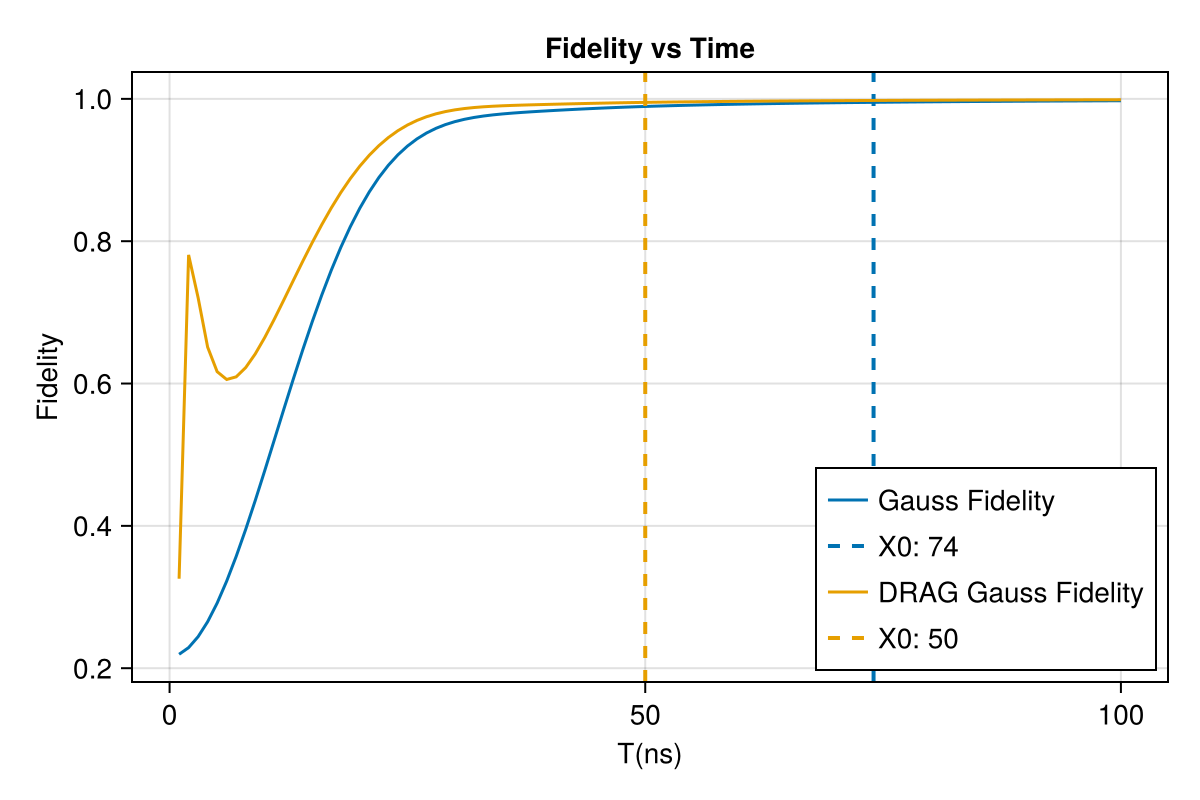

CairoMakie.Screen{IMAGE}


In [6]:
tolerance = 0.995

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Fidelity vs Time", xlabel = "T(ns)", ylabel = "Fidelity")
lines!(ax, fids_gauss; label = "Gauss Fidelity")
vlines!(ax, x0_checker(fids_gauss, tolerance), linewidth = 2, linestyle = :dash, label = "X0: $(x0_checker(fids_gauss, tolerance))")
lines!(ax, fids_DRAG_gauss; label = "DRAG Gauss Fidelity")
vlines!(ax, x0_checker(fids_DRAG_gauss, tolerance), linewidth = 2, linestyle = :dash, label = "X0: $(x0_checker(fids_DRAG_gauss, tolerance))")
axislegend(ax; position = :rb)
display(fig)

### Infidelity vs Time

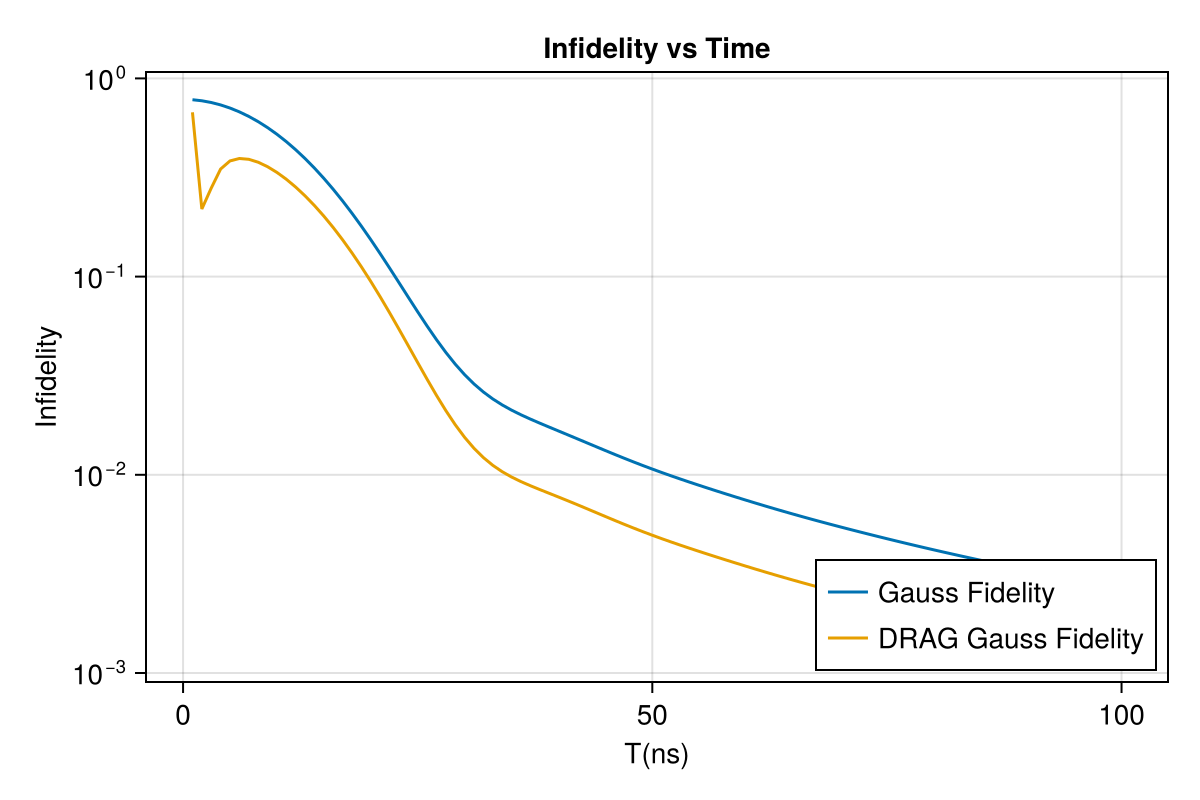

CairoMakie.Screen{IMAGE}


In [126]:
tolerance = 0.995

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], yscale = log10, title = "Infidelity vs Time", xlabel = "T(ns)", ylabel = "Infidelity")
lines!(ax, 1 .- fids_gauss; label = "Gauss Fidelity")
lines!(ax, 1 .- fids_DRAG_gauss; label = "DRAG Gauss Fidelity")
axislegend(ax; position = :rb)
display(fig)

### Fidelity vs Time Log_Scale

In [73]:
fids_gauss_log = []
fids_DRAG_gauss_log = []
xs = 10 .^ range(0, 5, length=100)

for i in xs
    push!(fids_gauss_log, fid_gauss_check(i))
    push!(fids_DRAG_gauss_log, fid_DRAG_gauss_check(i))
end

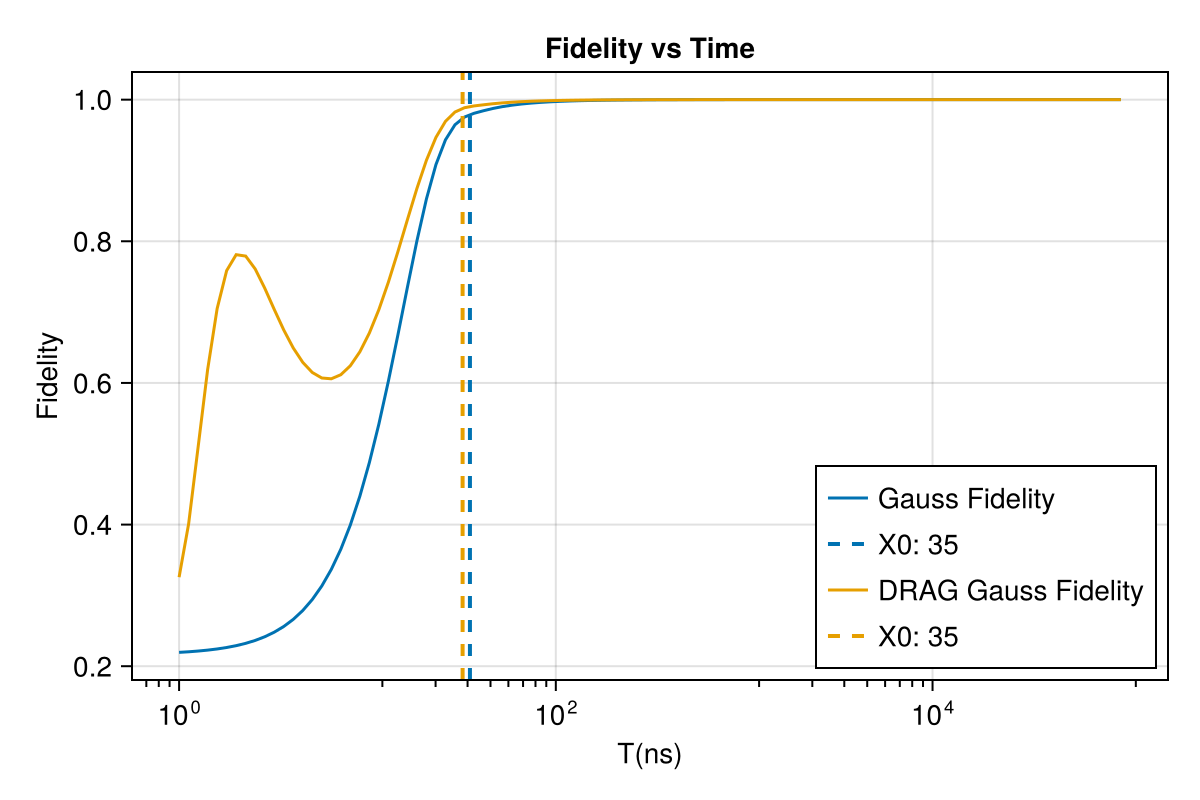

CairoMakie.Screen{IMAGE}


In [74]:
tolerance = 0.99

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], xscale = log10, xminorticksvisible = true, xminorticks = IntervalsBetween(9), title = "Fidelity vs Time", xlabel = "T(ns)", ylabel = "Fidelity")
lines!(ax, xs, fids_gauss_log; label = "Gauss Fidelity")

vlines!(ax, x0_checker(fids_gauss_log, tolerance), linewidth = 2, linestyle = :dash, label = "X0: $(x0_checker(fids_gauss_log, tolerance))")
lines!(ax, xs, fids_DRAG_gauss_log; label = "DRAG Gauss Fidelity")

vlines!(ax, x0_checker(fids_DRAG_gauss_log, tolerance), linewidth = 2, linestyle = :dash, label = "X0: $(x0_checker(fids_DRAG_gauss, tolerance))")
axislegend(ax; position = :rb)
display(fig)

# --------------------------------------------------

# Fake Initial Decoherence Graphs

- I tried to change the fidelity by just doing F_new = F_old * exp(-t/Tx)
- But the only way I could get this to work was by having T1 and T2 be ~ 10^2 * ns versus 10^3 * ns to be microseconds
- The graphs below try and do this and do it poorly
- They do however represent that with sufficient time T1 and decoherence will take over and bring fidelity to 0

In [ ]:
fids_gauss_log = []
fids_DRAG_gauss_log = []
xs = 10 .^ range(0, 6, length=100) 

for i in xs
    push!(fids_gauss_log, fid_gauss_check(i))
    push!(fids_DRAG_gauss_log, fid_DRAG_gauss_check(i))
end

In [115]:
T1 = 40 * 100
T2 = 25 * 100

function fid_changer_gauss(t, T1, T2)
    Tx = (1/2T1 + 1/T2)^-1
    F_new = fids_gauss_log[t] * exp(-t/Tx)
    return F_new
end

fid_changed_gauss_log = []
for i in range(1, size(fids_gauss_log)[1])
    push!(fid_changed_gauss_log, fid_changer_gauss(i, T1, T2))
end


### Long Term(Not long enough)

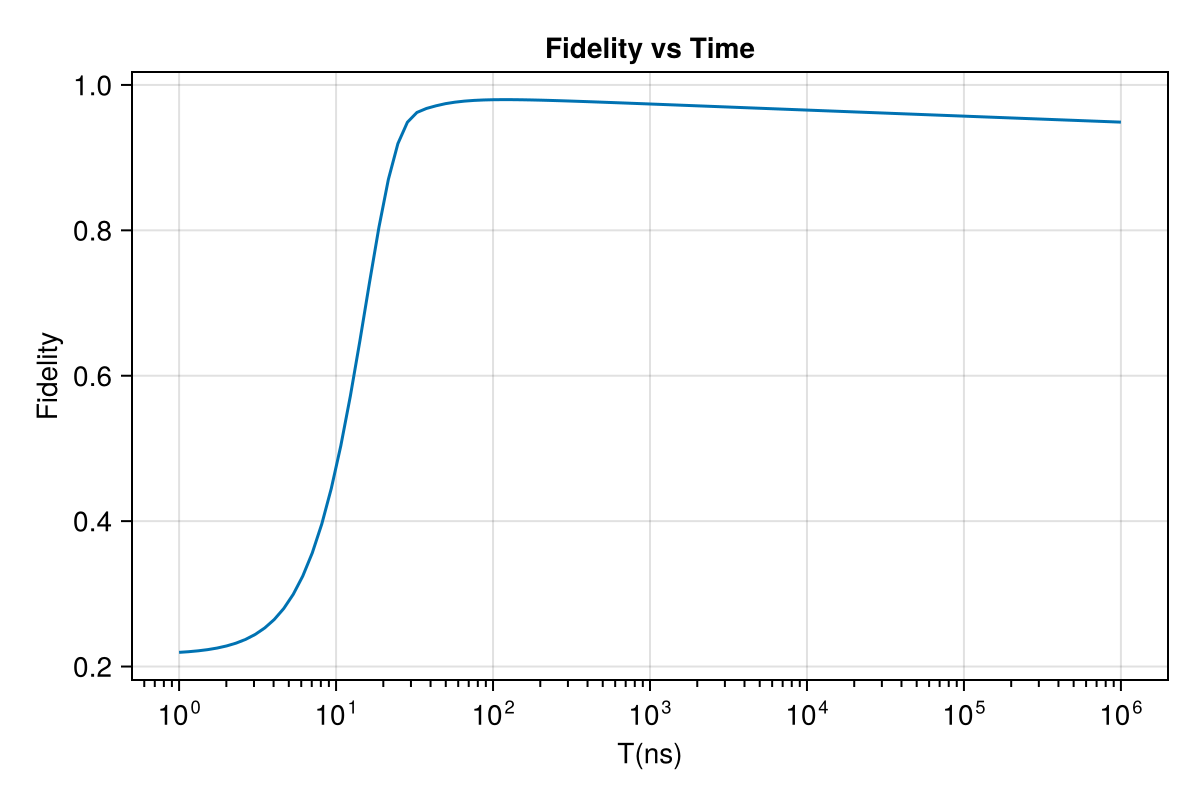

In [117]:
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], xscale = log10, xminorticksvisible = true, xminorticks = IntervalsBetween(9), title = "Fidelity vs Time", xlabel = "T(ns)", ylabel = "Fidelity")
lines!(ax, xs, fid_changed_gauss_log; label = "Gauss Fidelity")
fig

### Very short term

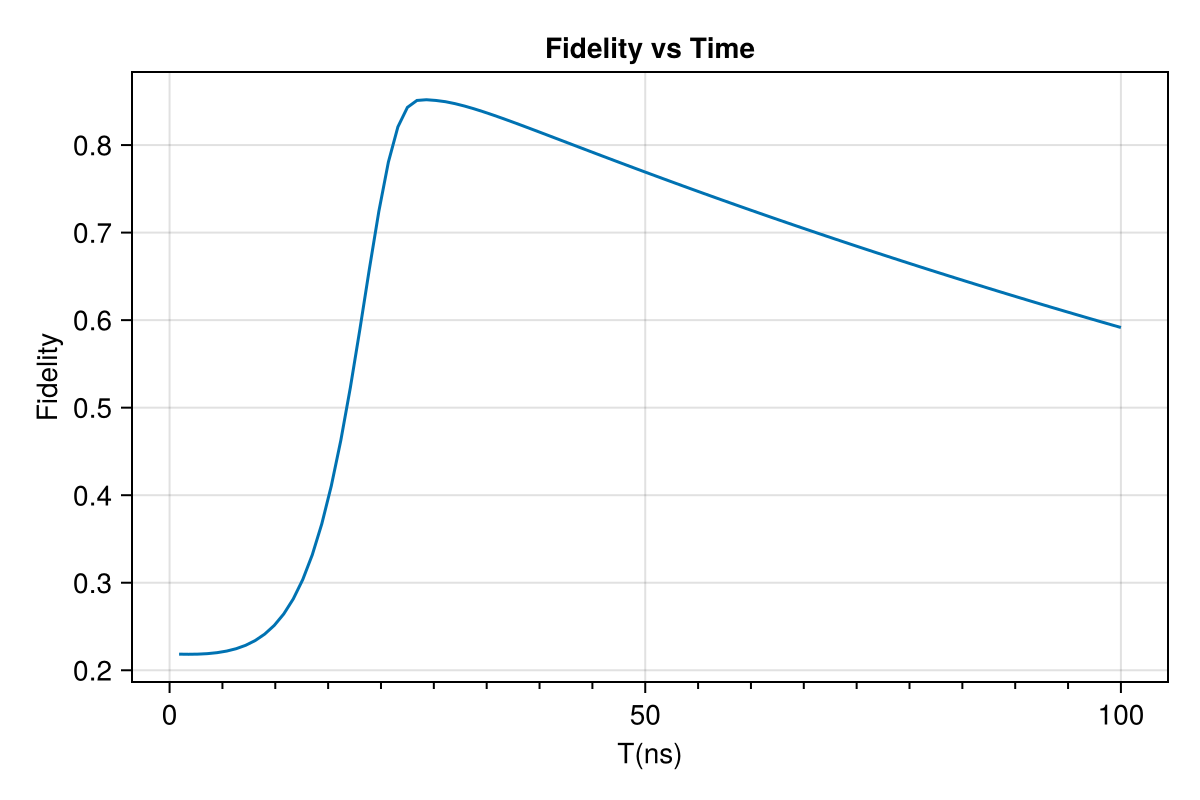

In [127]:

fid_changed_gauss2 = []
for i in range(1, size(fids_gauss)[1])
    push!(fid_changed_gauss2, fid_changer_gauss(i, 40 * 10, 25 * 10))
end

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], xminorticksvisible = true, xminorticks = IntervalsBetween(9), title = "Fidelity vs Time", xlabel = "T(ns)", ylabel = "Fidelity")
lines!(ax, fid_changed_gauss2; label = "Gauss Fidelity")
fig

### Infidelity

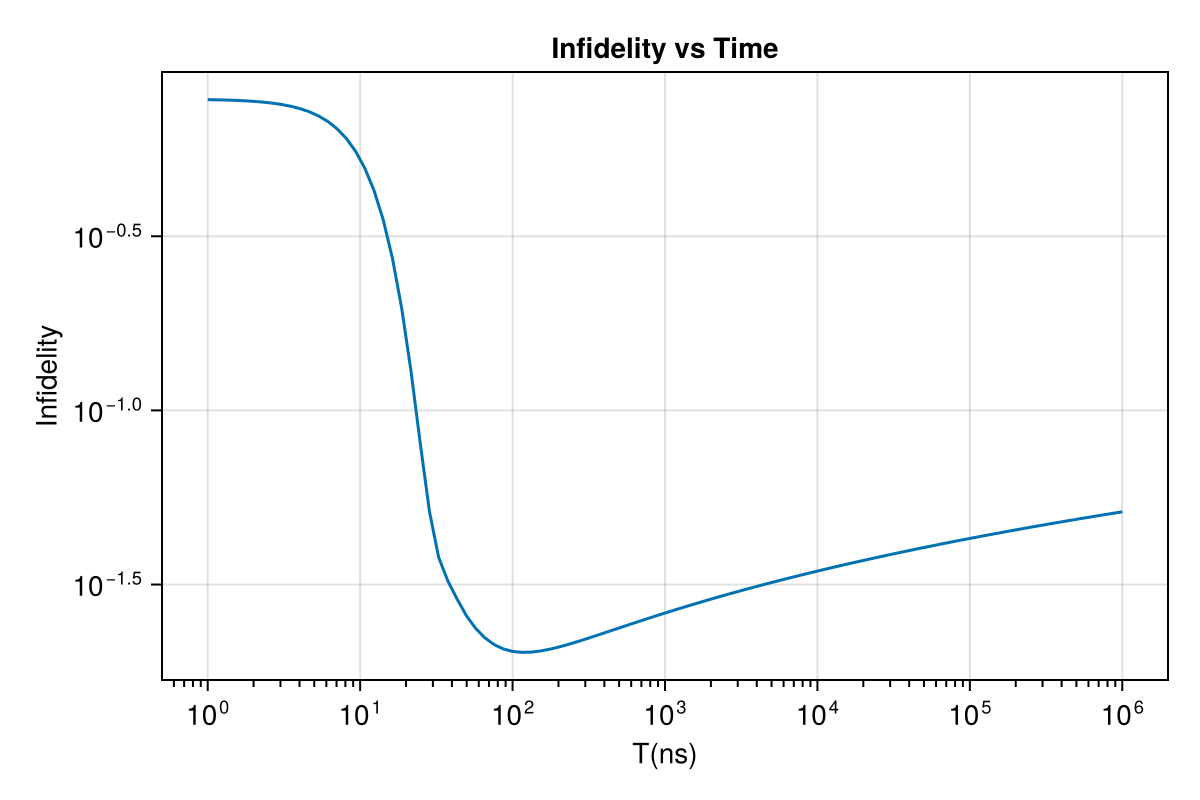

In [128]:
tolerance = 0.99

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], yscale = log10, xscale = log10, xminorticksvisible = true, xminorticks = IntervalsBetween(9), title = "Infidelity vs Time", xlabel = "T(ns)", ylabel = "Infidelity")
lines!(ax, xs, 1 .- fid_changed_gauss_log; label = "Gauss Fidelity")
fig